In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
P = np.array([[0.3553719 , 0.01652893, 0.23553719, 0.39256198],
       [0.66964286, 0.01785714, 0.17857143, 0.13392857],
       [0.15909091, 0.08181818, 0.25      , 0.50909091],
       [0.10823529, 0.20470588, 0.20705882, 0.48      ]])

nucleotides = ['A', 'C', 'G', 'T']
nt_to_idx = {nt:i for i, nt in enumerate(nucleotides)}

In [8]:
def generate_sequence(P, length, start_state):
    '''функция генерации последовательности по заданной метрице'''
    seq = [start_state]
    current_nt = start_state
    for _ in range(length-1):
        i = nt_to_idx[current_nt]
        next_nt = np.random.choice(nucleotides, p=P[i])
        seq.append(next_nt)
        current_nt = next_nt
    return ''.join(seq)


def dinucleotide_frequencies(seq):
    '''функция подсчета частот'''
    freq = np.zeros((4,4))
    for i in range(len(seq)-1):
        a = nt_to_idx[seq[i]]
        b = nt_to_idx[seq[i+1]]
        freq[a,b] += 1
    freq /= freq.sum()  
    return freq

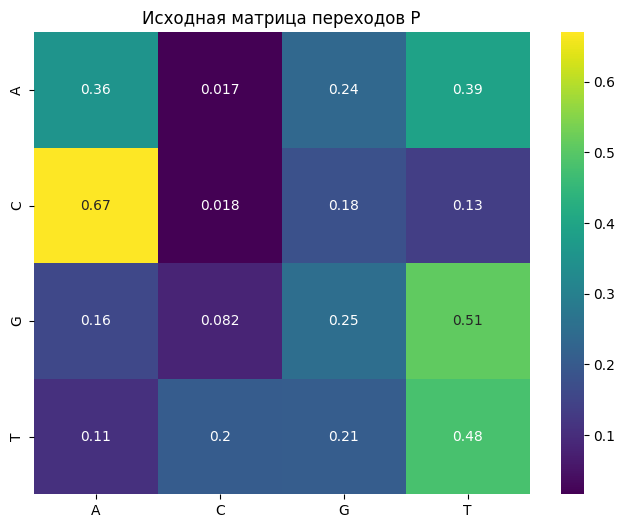

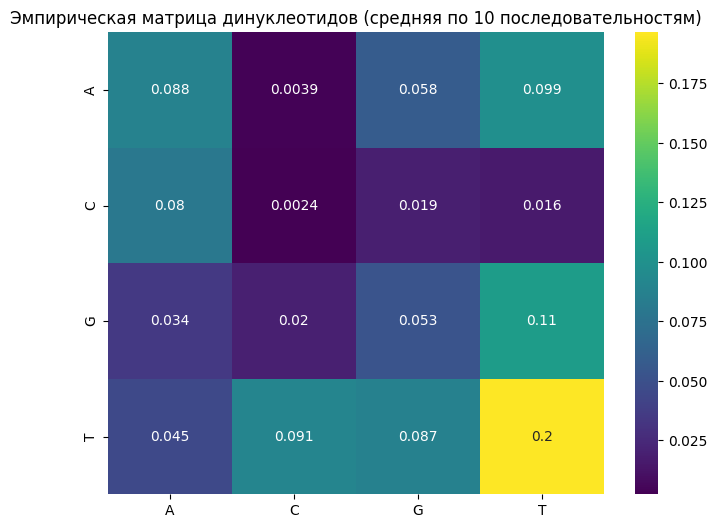

Среднее отклонение между P и эмпирической матрицей: 0.18749999937499998


In [9]:

# генерируем посл
sequences = [generate_sequence(P, 1000, 'A') for _ in range(10)]


# матрица по 10 посл
empirical_freqs = np.mean([dinucleotide_frequencies(s) for s in sequences], axis=0)

# хитмап исходной
plt.figure(figsize=(8,6))
sns.heatmap(P, annot=True, xticklabels=nucleotides, yticklabels=nucleotides, cmap='viridis')
plt.title("Исходная матрица переходов P")
plt.show()

# хитмап эмперической
plt.figure(figsize=(8,6))
sns.heatmap(empirical_freqs, annot=True, xticklabels=nucleotides, yticklabels=nucleotides, cmap='viridis')
plt.title("Эмпирическая матрица динуклеотидов (средняя по 10 последовательностям)")
plt.show()

diff = np.abs(P - empirical_freqs)
print("Среднее отклонение между P и эмпирической матрицей:", diff.mean())

In [10]:
# 10 последовательностей это не очень много и поэтому есть различия. но в целом общие тренды видны